In [20]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc

/var/folders/68/qnr9nmp13_b3p50cf0nx0rbm0000gn/T/ipykernel_17413/3283670876.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


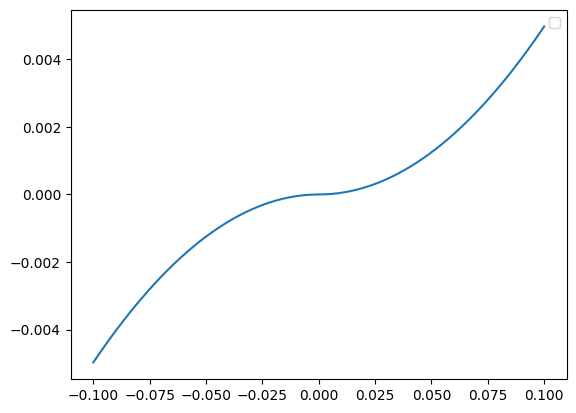

In [21]:
v = np.linspace(-0.1, 0.1, 1000)
v_eps = 1e-6
v_s = 1.0

# Coulomb friction constant
F_c = 0.5

# Stribeck friction constant
F_s = 0.

# Viscous friction constant
F_v = 0.

def F(v):
    return np.tanh(v / v_eps) * (F_c + (F_s - F_c) * np.exp(-(v / v_s) ** 2)) + F_v * v

plt.figure()
plt.plot(v, F(v))
# plt.plot(v, np.tanh(v / v_eps) * F_c, label="Coulomb friction")
plt.legend()

Text(0.5, 1.0, 'Chirp Force Input')

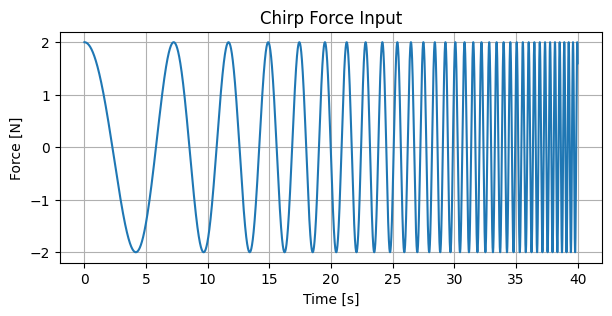

In [77]:
# Scipy chirp function for force

from scipy.signal import chirp

t0, tf = 0.0, 40.0
A = 2.0  # Forcing amplitude [N]
dt = 1e-3  # 1 kHz fine step for "truth"
tp = np.arange(t0, tf, dt)
up = A * chirp(tp, f0=0.1, f1=3.0, t1=tf, method='logarithmic')

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, up)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Force [N]')
ax.grid()
ax.set_title('Chirp Force Input')

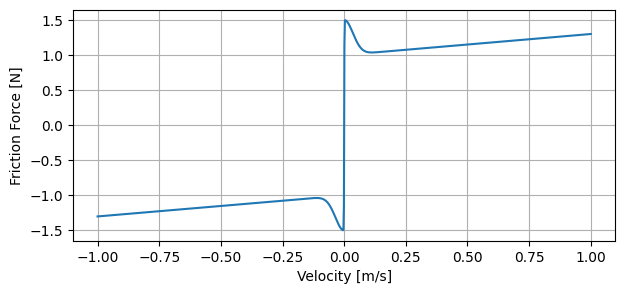

In [88]:
# Spring-mass-friction model

# Spring and mass parameters (assumed known/measurable)
m = 1.0  # mass [kg]
k = 25.0  # spring constant [N/m]

# Friction parameters (assumed unknown, including model form)
F_c = 1.0  # Coulomb friction constant [N]
F_s = 1.5  # Static/stiction peak friction constant [N]
v_s = 0.05  # Stribeck velocity [m/s]
F_v = 0.3  # Viscous friction constant [N/(m/s)]
v_eps = 1e-3  # Smoothing parameter for Coulomb friction [m/s]

def friction(v):
    return np.tanh(v / v_eps) * (F_c + (F_s - F_c) * np.exp(-(v / v_s) ** 2)) + F_v * v

v_plt = np.linspace(-1, 1, 1000)
f_plt = friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt)
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
ax.grid()
plt.show()

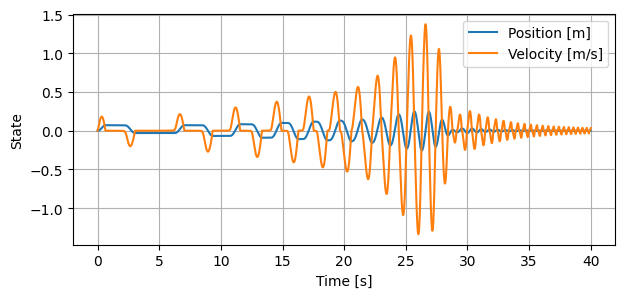

In [84]:

def ode_rhs(t, y):
    u = np.interp(t, tp, up)
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

y0 = np.array([0.0, 0.0])
ys = arc.odeint(ode_rhs, [t0, tf], y0, t_eval=tp)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, ys[0], label='Position [m]')
ax.plot(tp, ys[1], label='Velocity [m/s]')
ax.set_xlabel('Time [s]')
ax.set_ylabel('State')
ax.grid()
ax.legend()
plt.show()

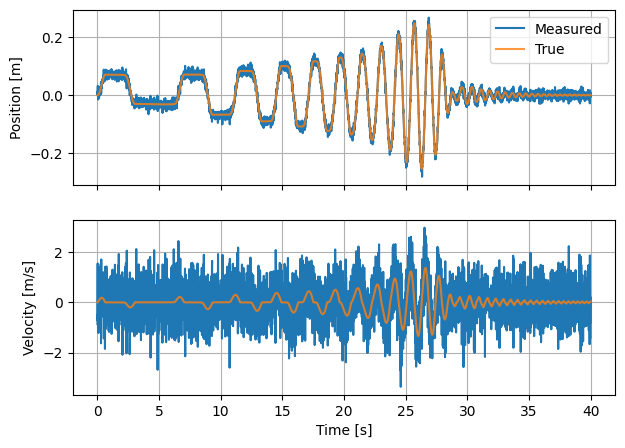

In [83]:
# Subsample to 100 Hz and add noise

ts = np.arange(t0, tf, 1e-2)
xs = np.interp(ts, tp, ys[0])
xs += 1e-2 * np.random.randn(len(xs))  # Add noise

fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(ts, xs, label="Measured")
ax[0].plot(tp, ys[0], alpha=0.8, label="True")
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()
vs_fd = np.gradient(xs, ts)
ax[1].plot(ts, vs_fd, label="Measured")
ax[1].plot(tp, ys[1], alpha=0.8, label="True")
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()
plt.show()